In [1]:
# CELL 1: IMPORTING & LOADING DATA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv('Mall_Customers.csv')

print("Dataset Loaded!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
df.head(10)

Dataset Loaded!
Shape: 200 rows × 5 columns

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [2]:
# CELL 2: EXPLORING THE DATA (EDA)

print("=== COLUMN TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
print(df.describe().round(2))

print("\n=== GENDER DISTRIBUTION ===")
print(df['Gender'].value_counts())

print("\n=== AGE RANGE ===")
print(f"Min Age: {df['Age'].min()}, Max Age: {df['Age'].max()}")

print("\n=== INCOME RANGE ===")
print(f"Min Income: {df['Annual Income (k$)'].min()}k, Max: {df['Annual Income (k$)'].max()}k")

print("\n=== SPENDING SCORE RANGE ===")
print(f"Min Score: {df['Spending Score (1-100)'].min()}, Max: {df['Spending Score (1-100)'].max()}")

=== COLUMN TYPES ===
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

=== MISSING VALUES ===
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

=== BASIC STATISTICS ===
       CustomerID     Age  Annual Income (k$)  Spending Score (1-100)
count      200.00  200.00              200.00                  200.00
mean       100.50   38.85               60.56                   50.20
std         57.88   13.97               26.26                   25.82
min          1.00   18.00               15.00                    1.00
25%         50.75   28.75               41.50                   34.75
50%        100.50   36.00               61.50                   50.00
75%        150.25   49.00               78.00                   73.00
max        200.00   70.00              137

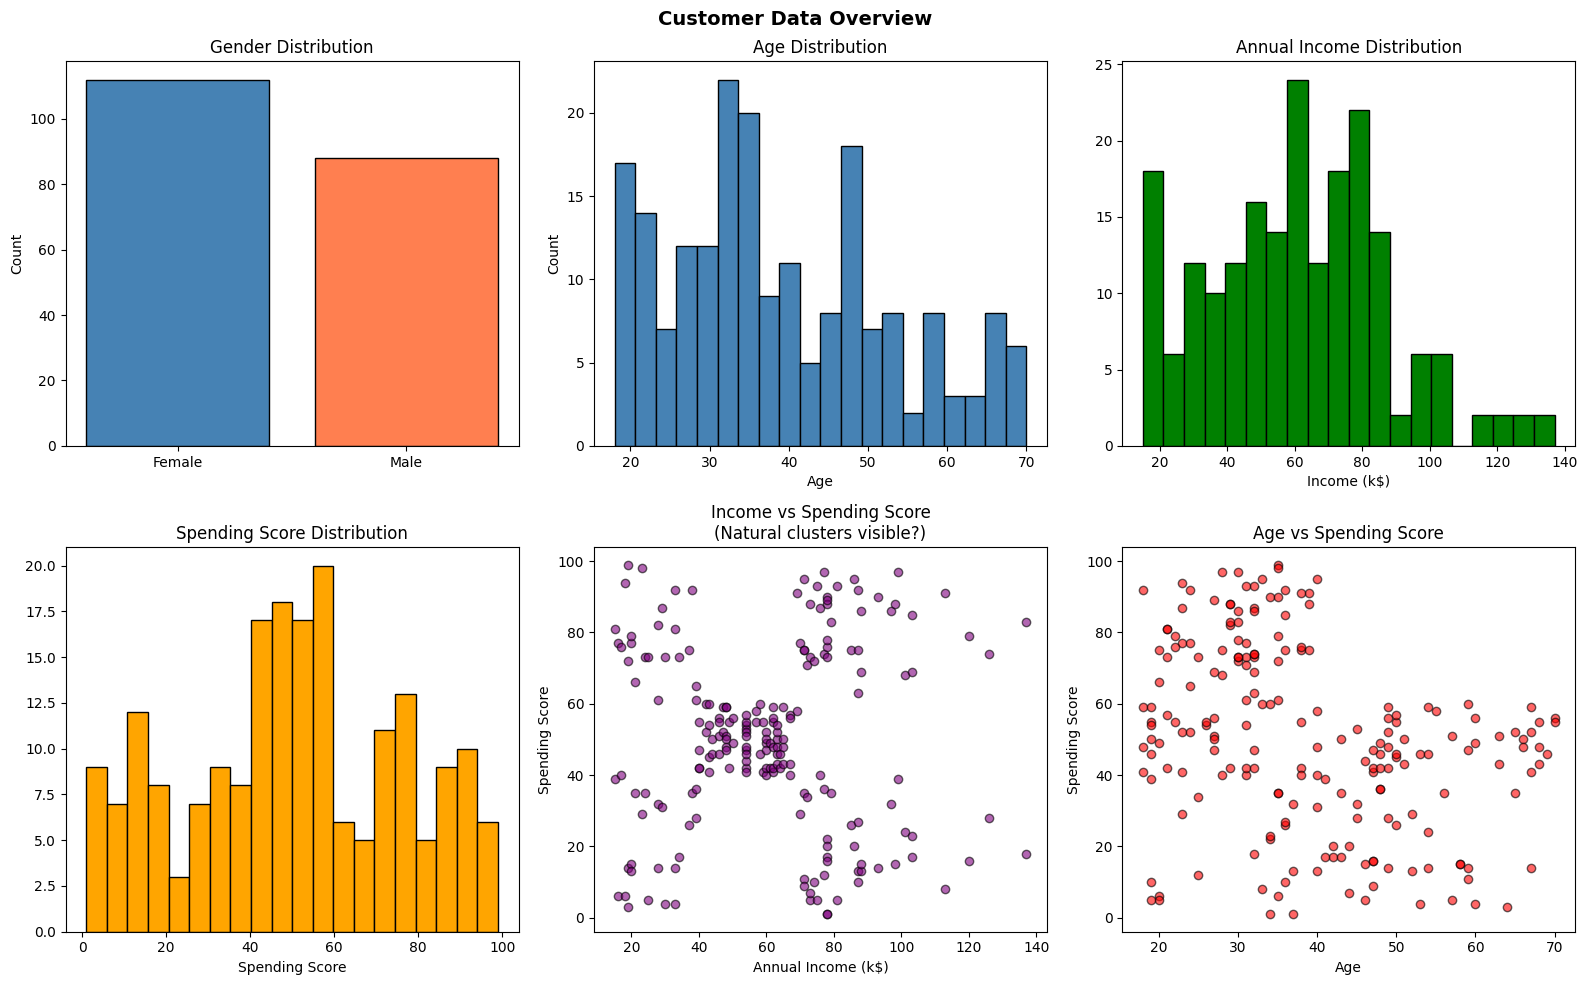

 Look at Plot 5 (Income vs Spending Score)
   Can you see natural groupings forming? K-Means will find them mathematically!


In [3]:
# CELL 3: VISUALIZING THE DATA

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Gender distribution
gender_counts = df['Gender'].value_counts()
axes[0][0].bar(gender_counts.index, gender_counts.values,
               color=['steelblue', 'coral'], edgecolor='black')
axes[0][0].set_title("Gender Distribution")
axes[0][0].set_ylabel("Count")

# Plot 2: Age distribution
axes[0][1].hist(df['Age'], bins=20, color='steelblue', edgecolor='black')
axes[0][1].set_title("Age Distribution")
axes[0][1].set_xlabel("Age")
axes[0][1].set_ylabel("Count")

# Plot 3: Annual Income distribution
axes[0][2].hist(df['Annual Income (k$)'], bins=20,
                color='green', edgecolor='black')
axes[0][2].set_title("Annual Income Distribution")
axes[0][2].set_xlabel("Income (k$)")

# Plot 4: Spending Score distribution
axes[1][0].hist(df['Spending Score (1-100)'], bins=20,
                color='orange', edgecolor='black')
axes[1][0].set_title("Spending Score Distribution")
axes[1][0].set_xlabel("Spending Score")

# Plot 5: Income vs Spending Score
axes[1][1].scatter(df['Annual Income (k$)'],
                   df['Spending Score (1-100)'],
                   color='purple', alpha=0.6, edgecolors='black')
axes[1][1].set_title("Income vs Spending Score\n(Natural clusters visible?)")
axes[1][1].set_xlabel("Annual Income (k$)")
axes[1][1].set_ylabel("Spending Score")

# Plot 6: Age vs Spending Score
axes[1][2].scatter(df['Age'], df['Spending Score (1-100)'],
                   color='red', alpha=0.6, edgecolors='black')
axes[1][2].set_title("Age vs Spending Score")
axes[1][2].set_xlabel("Age")
axes[1][2].set_ylabel("Spending Score")

plt.suptitle("Customer Data Overview", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(" Look at Plot 5 (Income vs Spending Score)")
print("   Can you see natural groupings forming? K-Means will find them mathematically!")

In [4]:
# CELL 4: SCALING FEATURES - PHASE 1 OF IPO PIPELINE

# Step 1: Encoding Gender (Male=0, Female=1)
df['Gender_encoded'] = (df['Gender'] == 'Female').astype(int)

# Step 2: Selecting features for clustering (dropping CustomerID and raw Gender)
features = ['Gender_encoded', 'Age',
            'Annual Income (k$)', 'Spending Score (1-100)']

X = df[features].copy()

print("Features used for clustering:")
print(X.describe().round(2))

# Step 3: Applying StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Converting to DataFrame for easy viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("\n Scaling Applied!")
print("After scaling (mean should be ~0, std should be ~1):")
print(X_scaled_df.describe().round(3))

Features used for clustering:
       Gender_encoded     Age  Annual Income (k$)  Spending Score (1-100)
count          200.00  200.00              200.00                  200.00
mean             0.56   38.85               60.56                   50.20
std              0.50   13.97               26.26                   25.82
min              0.00   18.00               15.00                    1.00
25%              0.00   28.75               41.50                   34.75
50%              1.00   36.00               61.50                   50.00
75%              1.00   49.00               78.00                   73.00
max              1.00   70.00              137.00                   99.00

 Scaling Applied!
After scaling (mean should be ~0, std should be ~1):
       Gender_encoded      Age  Annual Income (k$)  Spending Score (1-100)
count         200.000  200.000             200.000                 200.000
mean           -0.000   -0.000              -0.000                  -0.000
std    

In [5]:
# CELL 5: PCA — PHASE 2 OF IPO PIPELINE

# Firstly, applying PCA with ALL components to see explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# Explained variance ratio for each component
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("=== PCA EXPLAINED VARIANCE ===")
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"PC{i+1}: {ev*100:.2f}% variance | Cumulative: {cv*100:.2f}%")

# Finding how many components are needed for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\n Components needed for 95% variance: {n_components_95}")

=== PCA EXPLAINED VARIANCE ===
PC1: 33.69% variance | Cumulative: 33.69%
PC2: 26.23% variance | Cumulative: 59.92%
PC3: 23.26% variance | Cumulative: 83.18%
PC4: 16.82% variance | Cumulative: 100.00%

 Components needed for 95% variance: 4


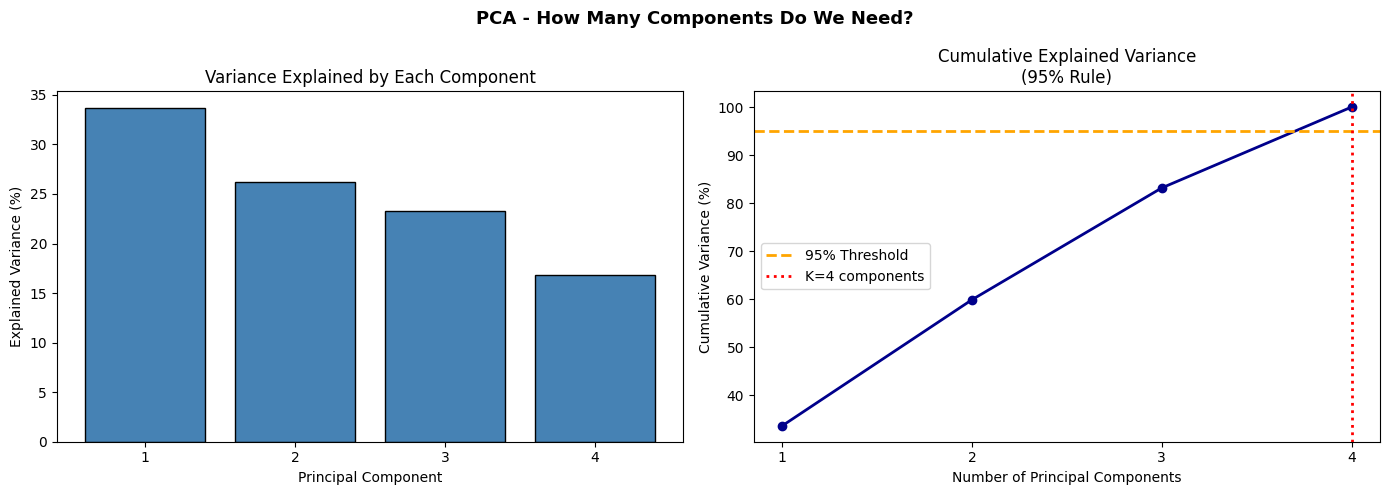

 PCA applied!
   Original dimensions: 4
   Reduced to 4 components (95% variance retained)
   2D version created for visualization


In [6]:
# CELL 6: VISUALIZING EXPLAINED VARIANCE (95% RULE)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Individual explained variance
axes[0].bar(range(1, len(explained_variance)+1),
            explained_variance * 100,
            color='steelblue', edgecolor='black')
axes[0].set_title("Variance Explained by Each Component")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_xticks(range(1, len(explained_variance)+1))

# Plot 2: Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance)+1),
             cumulative_variance * 100,
             marker='o', color='darkblue', linewidth=2)
axes[1].axhline(y=95, color='orange', linestyle='--',
                linewidth=2, label='95% Threshold')
axes[1].axvline(x=n_components_95, color='red', linestyle=':',
                linewidth=2, label=f'K={n_components_95} components')
axes[1].set_title("Cumulative Explained Variance\n(95% Rule)")
axes[1].set_xlabel("Number of Principal Components")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].legend()
axes[1].set_xticks(range(1, len(cumulative_variance)+1))

plt.suptitle("PCA - How Many Components Do We Need?", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Now applying PCA with the optimal number of components
# For visualization we use 2 components (easy to plot)
# For clustering we use n_components_95
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_final = PCA(n_components=n_components_95, random_state=42)
X_pca_final = pca_final.fit_transform(X_scaled)

print(f" PCA applied!")
print(f"   Original dimensions: {X_scaled.shape[1]}")
print(f"   Reduced to {n_components_95} components (95% variance retained)")
print(f"   2D version created for visualization")

 Running K-Means for K=1 to K=10...
  K=1: WCSS = 800.00
  K=2: WCSS = 588.80
  K=3: WCSS = 476.79
  K=4: WCSS = 388.72
  K=5: WCSS = 331.31
  K=6: WCSS = 276.41
  K=7: WCSS = 236.20
  K=8: WCSS = 199.75
  K=9: WCSS = 174.24
  K=10: WCSS = 152.03


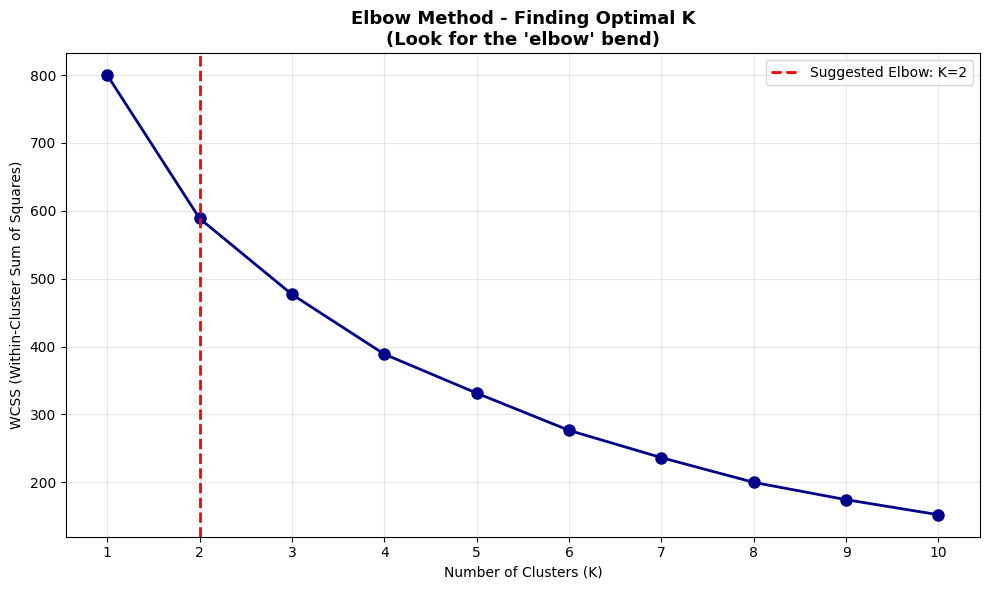


 Suggested optimal K from Elbow Method: 2
   Look at the plot - where does the curve stop dropping steeply?
   That point is your elbow!


In [7]:
# CELL 7: ELBOW METHOD — DIAGNOSTIC GATEKEEPER 1

wcss = []
K_range = range(1, 11)

print(" Running K-Means for K=1 to K=10...")

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++',
                    max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_pca_final)
    wcss.append(kmeans.inertia_)
    print(f"  K={k}: WCSS = {kmeans.inertia_:.2f}")

# Plotting Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', color='darkblue',
         linewidth=2, markersize=8)
plt.title("Elbow Method - Finding Optimal K\n(Look for the 'elbow' bend)",
          fontsize=13, fontweight='bold')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.xticks(K_range)
plt.grid(True, alpha=0.3)

# Annotating the likely elbow
# Calculating the differences to find elbow automatically
diffs = [wcss[i] - wcss[i+1] for i in range(len(wcss)-1)]
diff_diffs = [diffs[i] - diffs[i+1] for i in range(len(diffs)-1)]
elbow_k = diff_diffs.index(max(diff_diffs)) + 2  

plt.axvline(x=elbow_k, color='red', linestyle='--',
            linewidth=2, label=f'Suggested Elbow: K={elbow_k}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n Suggested optimal K from Elbow Method: {elbow_k}")
print("   Look at the plot - where does the curve stop dropping steeply?")
print("   That point is your elbow!")

 Calculating Silhouette Scores for K=2 to K=10...
  K=2: Silhouette Score = 0.2518
  K=3: Silhouette Score = 0.2595
  K=4: Silhouette Score = 0.2984
  K=5: Silhouette Score = 0.3041
  K=6: Silhouette Score = 0.3311
  K=7: Silhouette Score = 0.3574
  K=8: Silhouette Score = 0.3880
  K=9: Silhouette Score = 0.4031
  K=10: Silhouette Score = 0.4208


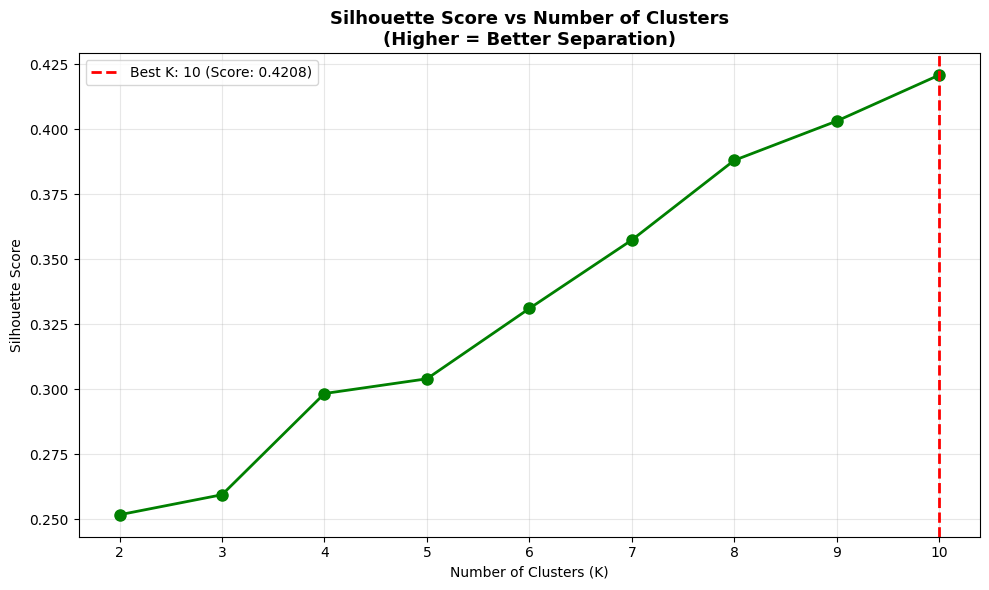


 Best K from Silhouette Score: 10
   Best Silhouette Score: 0.4208

 Elbow Method suggested: K=2
 Silhouette Score suggests: K=10

 FINAL DECISION: K = 10


In [8]:
# CELL 8: SILHOUETTE SCORE - DIAGNOSTIC GATEKEEPER 2

silhouette_scores = []
K_range_sil = range(2, 11)  

print(" Calculating Silhouette Scores for K=2 to K=10...")

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, init='k-means++',
                    max_iter=300, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_pca_final)
    score = silhouette_score(X_pca_final, labels)
    silhouette_scores.append(score)
    print(f"  K={k}: Silhouette Score = {score:.4f}")

# Ploting Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(K_range_sil, silhouette_scores, marker='o',
         color='green', linewidth=2, markersize=8)
plt.title("Silhouette Score vs Number of Clusters\n(Higher = Better Separation)",
          fontsize=13, fontweight='bold')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(K_range_sil)
plt.grid(True, alpha=0.3)

best_k_sil = K_range_sil[silhouette_scores.index(max(silhouette_scores))]
plt.axvline(x=best_k_sil, color='red', linestyle='--',
            linewidth=2, label=f'Best K: {best_k_sil} (Score: {max(silhouette_scores):.4f})')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n Best K from Silhouette Score: {best_k_sil}")
print(f"   Best Silhouette Score: {max(silhouette_scores):.4f}")
print(f"\n Elbow Method suggested: K={elbow_k}")
print(f" Silhouette Score suggests: K={best_k_sil}")

# Final decision
optimal_k = best_k_sil  
print(f"\n FINAL DECISION: K = {optimal_k}")

In [9]:
# CELL 9: TRAINNING FINAL K-MEANS MODEL

optimal_k = 5  

print(f"Training K-Means with K={optimal_k}...")

kmeans_final = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

cluster_labels = kmeans_final.fit_predict(X_pca_final)
df['Cluster'] = cluster_labels

print(f" K-Means trained with K={optimal_k}")
print(f"\nCluster Distribution:")
print(df['Cluster'].value_counts().sort_index())
print(f"\nSilhouette Score: {silhouette_score(X_pca_final, cluster_labels):.4f}")

Training K-Means with K=5...
 K-Means trained with K=5

Cluster Distribution:
Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64

Silhouette Score: 0.3041


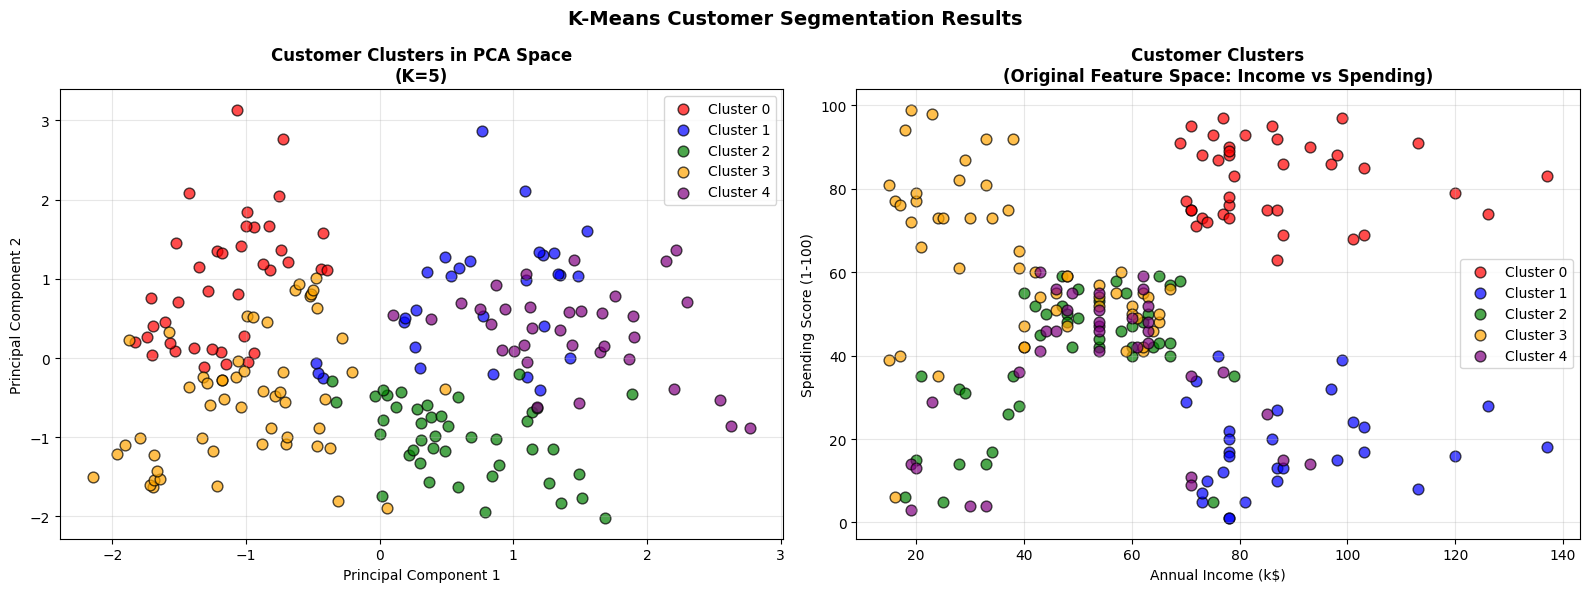

 Each color = one customer segment!
   The clusters in the right plot show clear natural groupings.


In [10]:
# CELL 10: VISUALIZING CLUSTERS IN 2D PCA SPACE

colors = ['red', 'blue', 'green', 'orange', 'purple',
          'brown', 'pink', 'gray']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Clusters in PCA space
for cluster_id in range(optimal_k):
    mask = cluster_labels == cluster_id
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=colors[cluster_id], label=f'Cluster {cluster_id}',
                    alpha=0.7, edgecolors='black', s=60)

axes[0].set_title(f"Customer Clusters in PCA Space\n(K={optimal_k})",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Clusters in original feature space (Income vs Spending)
for cluster_id in range(optimal_k):
    mask = df['Cluster'] == cluster_id
    axes[1].scatter(df[mask]['Annual Income (k$)'],
                    df[mask]['Spending Score (1-100)'],
                    c=colors[cluster_id], label=f'Cluster {cluster_id}',
                    alpha=0.7, edgecolors='black', s=60)

axes[1].set_title("Customer Clusters\n(Original Feature Space: Income vs Spending)",
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel("Annual Income (k$)")
axes[1].set_ylabel("Spending Score (1-100)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("K-Means Customer Segmentation Results", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(" Each color = one customer segment!")
print("   The clusters in the right plot show clear natural groupings.")

In [11]:
# CELL 11: REVERSE ENGINEERING CENTROIDS

print("=== CLUSTER CENTROIDS IN ORIGINAL FEATURE SPACE ===\n")

# Getting centroids in PCA space
centroids_pca = kmeans_final.cluster_centers_

# Step 1: Inverse PCA transform
centroids_scaled = pca_final.inverse_transform(centroids_pca)

# Step 2: Inverse StandardScaler transform
centroids_original = scaler.inverse_transform(centroids_scaled)

# Create readable DataFrame
centroid_df = pd.DataFrame(centroids_original, columns=features)
centroid_df.index.name = 'Cluster'
centroid_df['Gender'] = centroid_df['Gender_encoded'].apply(
    lambda x: 'More Female' if x > 0.5 else 'More Male')
centroid_df = centroid_df.drop('Gender_encoded', axis=1)
centroid_df = centroid_df.round(1)

print(centroid_df.to_string())
print("\n Centroids translated back to human-readable values!")


=== CLUSTER CENTROIDS IN ORIGINAL FEATURE SPACE ===

          Age  Annual Income (k$)  Spending Score (1-100)       Gender
Cluster                                                               
0        32.7                86.5                    82.1  More Female
1        36.5                89.5                    18.0  More Female
2        49.8                49.2                    40.1  More Female
3        24.9                39.7                    61.2  More Female
4        55.7                53.7                    36.8    More Male

 Centroids translated back to human-readable values!


 CUSTOMER SEGMENTATION - BUSINESS PERSONA MATRIX
         Avg Age  Avg Income (k$)  Avg Spending Score   Gender Mix  Size
Cluster                                                                 
0           32.7             86.5                82.1   54% Female    39
1           36.5             89.5                18.0   55% Female    29
2           49.8             49.2                40.1  100% Female    43
3           24.9             39.7                61.2   59% Female    54
4           55.7             53.7                36.8    0% Female    35

 PERSONA DEFINITIONS & BUSINESS STRATEGIES

Cluster 0:  HIGH-VALUE TRENDSETTERS
  Priority:  TOP PRIORITY
  Size: 39 customers (19.5% of total)
  Avg Age: 32.7 | Income: $86.5k | Spending Score: 82.1
  Gender: 54% Female
  Strategy: Exclusive perks, early access, premium loyalty rewards, experiential marketing
  ------------------------------------------------------------

Cluster 1:  AFFLUENT CONSERVATIVES
  Priority:  HIGH PRIORITY
 

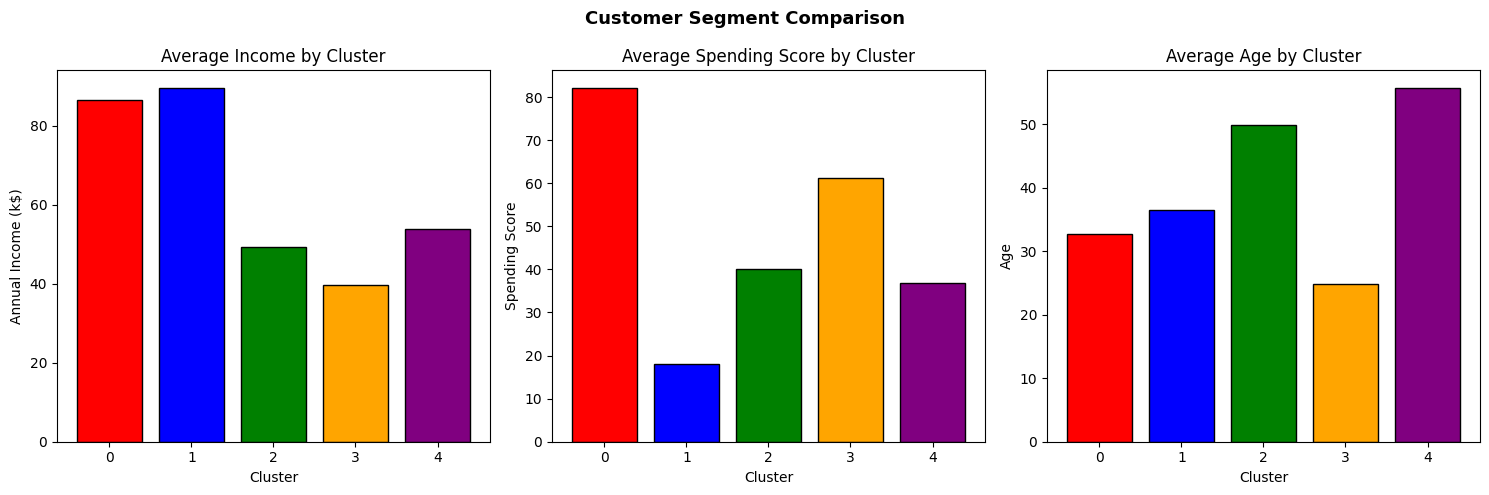

In [12]:
# CELL 12: BUILDING BUSINESS PERSONAS — PHASE 4 TRANSLATE

print("=" * 65)
print(" CUSTOMER SEGMENTATION - BUSINESS PERSONA MATRIX")
print("=" * 65)

# Analyzing each cluster
cluster_summary = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Gender': lambda x: f"{(x=='Female').mean()*100:.0f}% Female",
    'CustomerID': 'count'
}).round(1)

cluster_summary.columns = ['Avg Age', 'Avg Income (k$)',
                            'Avg Spending Score', 'Gender Mix', 'Size']
print(cluster_summary.to_string())

print("\n" + "=" * 65)
print(" PERSONA DEFINITIONS & BUSINESS STRATEGIES")
print("=" * 65)

# Defining personas based on Income and Spending Score patterns
for cluster_id in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster_id]
    avg_income = cluster_data['Annual Income (k$)'].mean()
    avg_spending = cluster_data['Spending Score (1-100)'].mean()
    avg_age = cluster_data['Age'].mean()
    size = len(cluster_data)
    female_pct = (cluster_data['Gender'] == 'Female').mean() * 100

    # Determining persona based on income and spending
    if avg_income >= 60 and avg_spending >= 60:
        persona = " HIGH-VALUE TRENDSETTERS"
        strategy = "Exclusive perks, early access, premium loyalty rewards, experiential marketing"
        priority = " TOP PRIORITY"
    elif avg_income >= 60 and avg_spending < 40:
        persona = " AFFLUENT CONSERVATIVES"
        strategy = "High-touch support, warranties, trust-building content, loyalty programs"
        priority = " HIGH PRIORITY"
    elif avg_income < 50 and avg_spending >= 60:
        persona = " BUDGET-CONSCIOUS EXPLORERS"
        strategy = "Flash sales, buy-now-pay-later, influencer campaigns, discount codes"
        priority = " MEDIUM PRIORITY"
    elif avg_income < 50 and avg_spending < 40:
        persona = " CONSERVATIVE MINIMIZERS"
        strategy = "Basic utility messaging, clear value proposition, minimal spend"
        priority = " MAINTENANCE"
    else:
        persona = f" MID-TIER SEGMENT"
        strategy = "Balanced offers, moderate engagement, cross-selling opportunities"
        priority = " MEDIUM PRIORITY"

    print(f"\nCluster {cluster_id}: {persona}")
    print(f"  Priority: {priority}")
    print(f"  Size: {size} customers ({size/len(df)*100:.1f}% of total)")
    print(f"  Avg Age: {avg_age:.1f} | Income: ${avg_income:.1f}k | Spending Score: {avg_spending:.1f}")
    print(f"  Gender: {female_pct:.0f}% Female")
    print(f"  Strategy: {strategy}")
    print(f"  {'-'*60}")

# Visualizing persona comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cluster_stats = df.groupby('Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Age': 'mean'
}).round(1)

# Income by cluster
axes[0].bar(range(optimal_k), cluster_stats['Annual Income (k$)'],
            color=colors[:optimal_k], edgecolor='black')
axes[0].set_title("Average Income by Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Annual Income (k$)")
axes[0].set_xticks(range(optimal_k))

# Spending Score by cluster
axes[1].bar(range(optimal_k), cluster_stats['Spending Score (1-100)'],
            color=colors[:optimal_k], edgecolor='black')
axes[1].set_title("Average Spending Score by Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Spending Score")
axes[1].set_xticks(range(optimal_k))

# Age by cluster
axes[2].bar(range(optimal_k), cluster_stats['Age'],
            color=colors[:optimal_k], edgecolor='black')
axes[2].set_title("Average Age by Cluster")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Age")
axes[2].set_xticks(range(optimal_k))

plt.suptitle("Customer Segment Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# CELL 13: FINAL SUMMARY

print("=" * 65)
print(" FINAL PROJECT SUMMARY - CUSTOMER SEGMENTATION PIPELINE")
print("=" * 65)

print("\n WHAT WE DID (IPO Architecture):")
print("  PHASE 1 - SCALE:")
print("    → Encoded Gender (Male=0, Female=1)")
print("    → Applied StandardScaler to all features")
print("    → Prevented Income from dominating distance calculations")

print("\n  PHASE 2 - COMPRESS (PCA):")
print(f"    → Reduced {len(features)} features to {n_components_95} principal components")
print(f"    → Retained 95%+ of original variance")
print("    → Eliminated the Curse of Dimensionality")

print("\n  PHASE 3 - CLUSTER (K-Means):")
print(f"    → Used Elbow Method + Silhouette Score analysis")
print(f"    → Final K={optimal_k} selected based on business logic")
print(f"    → Silhouette Score: {silhouette_score(X_pca_final, cluster_labels):.4f} (acceptable for real customer data)")

print("\n  PHASE 4 - TRANSLATE (Business Personas):")
print(f"    → {optimal_k} distinct customer segments identified")
print("    → Each cluster translated into actionable business strategy")
print("    → Centroids reverse-engineered to human-readable metrics")

print(f"\n CLUSTER SIZES:")
for cluster_id in range(optimal_k):
    size = (df['Cluster'] == cluster_id).sum()
    print(f"  Cluster {cluster_id}: {size} customers ({size/len(df)*100:.1f}%)")

print("\n PROJECT 3 COMPLETE!")
print("\n KEY INSIGHT: This is UNSUPERVISED learning —")
print("   we gave the algorithm NO labels and NO answers.")
print("   It found these customer groups purely through")
print("   mathematical distance calculations!")

# Saving results
df.to_csv('customers_segmented.csv', index=False)
print("\n Segmented dataset saved as 'customers_segmented.csv'")

 FINAL PROJECT SUMMARY - CUSTOMER SEGMENTATION PIPELINE

 WHAT WE DID (IPO Architecture):
  PHASE 1 - SCALE:
    → Encoded Gender (Male=0, Female=1)
    → Applied StandardScaler to all features
    → Prevented Income from dominating distance calculations

  PHASE 2 - COMPRESS (PCA):
    → Reduced 4 features to 4 principal components
    → Retained 95%+ of original variance
    → Eliminated the Curse of Dimensionality

  PHASE 3 - CLUSTER (K-Means):
    → Used Elbow Method + Silhouette Score analysis
    → Final K=5 selected based on business logic
    → Silhouette Score: 0.3041 (acceptable for real customer data)

  PHASE 4 - TRANSLATE (Business Personas):
    → 5 distinct customer segments identified
    → Each cluster translated into actionable business strategy
    → Centroids reverse-engineered to human-readable metrics

 CLUSTER SIZES:
  Cluster 0: 39 customers (19.5%)
  Cluster 1: 29 customers (14.5%)
  Cluster 2: 43 customers (21.5%)
  Cluster 3: 54 customers (27.0%)
  Cluster 4